## *Course Project / Maj Hakalax*


### *How can I use this notebook?*
Run the cells from top to bottom (or select run all from the run menu). 
The dataset used in this notebook is Sample - Superstore.csv and is included in the repository. 
Pandas, matplotlib, seaborn and IPython are imported in the first code cell and are used througout the notebook.

### **Introduction**

The dataset is sourced from Kaggle and contains historical transaction data from "Superstore," a fictional US-based retailer.

This project is based around a fictional case in which Superstore is looking to open its first physical retail store. The target customer segment is consumers (B2C), and the analysis aims to provide data-driven recommendations on three key questions:
*Which region to enter?* , *Which cities to prioritize?*, and *How to allocate shelf space across product categories?*



<img src="pipeline.png" width="400"/>

### **I. Extracting and Cleaning the Data**

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Preview the data 
display(df.head())
print(f"Total rows: {len(df)}")

# Checking for missing values, duplicated rows and data types
display(f"Missing vales: {df.isnull().sum()}")
display(f"Duplicated rows: {df.duplicated().sum()}")
display(df.dtypes)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Total rows: 9994


'Missing vales: Row ID           0\nOrder ID         0\nOrder Date       0\nShip Date        0\nShip Mode        0\nCustomer ID      0\nCustomer Name    0\nSegment          0\nCountry          0\nCity             0\nState            0\nPostal Code      0\nRegion           0\nProduct ID       0\nCategory         0\nSub-Category     0\nProduct Name     0\nSales            0\nQuantity         0\nDiscount         0\nProfit           0\ndtype: int64'

'Duplicated rows: 0'

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [107]:
# Filtering out B2B data and keepig only relevant columns 
df_clean = df[df['Segment'] == 'Consumer'][['Region', 'City', 'Category', 'Sales', 'Profit']]
print(df_clean.head())

  Region             City         Category     Sales    Profit
0  South        Henderson        Furniture  261.9600   41.9136
1  South        Henderson        Furniture  731.9400  219.5820
3  South  Fort Lauderdale        Furniture  957.5775 -383.0310
4  South  Fort Lauderdale  Office Supplies   22.3680    2.5164
5   West      Los Angeles        Furniture   48.8600   14.1694


**No missing values** or **duplicate rows** were found in the dataset. The Order Date column is stored as a string object rather than a datetime type, however this does not affect the analysis as no time-based analysis is conducted. Since the store targets consumer (B2C) sales, **all rows corresponding to corporate (B2B) transactions were filtered out**. The analysis uses the following columns: Region, City, Category, Sales, and Profit.

### **II. Regional Analysis**
To identify the most attractive region for the new store, three metrics are evaluated per region: **total sales**, **total profit**, and **profit margin**. Average sales per order is also calculated as a sanity check to ensure results are not skewed by a small number of unusually large orders.


In [108]:
# Total sales per region
region_sales = df_clean.groupby('Region')['Sales'].sum().reset_index() 
region_sales.columns = ['Region', 'Total Sales']
display(region_sales.sort_values('Total Sales', ascending=False))

# Total profit per region
region_profit = df_clean.groupby('Region')['Profit'].sum().reset_index()
region_profit.columns = ['Region','Total Profit']
display(region_profit.sort_values('Total Profit', ascending=False))

# Average sales per order for each region
region_average = df_clean.groupby('Region')['Sales'].mean().reset_index()
region_average.columns = ['Region', 'Average Sales Per Order']
display(region_average.sort_values('Average Sales Per Order', ascending=False))

,Region,Total Sales
3,West,362880.773
1,East,350908.167
0,Central,252031.434
2,South,195580.971


,Region,Total Profit
3,West,57450.6040
1,East,41190.9843
2,South,26913.5728
0,Central,8564.0481


,Region,Average Sales Per Order
1,East,238.875539
2,South,233.390180
3,West,217.033955
0,Central,207.946728


In [109]:
# Profit margin for each region
region_summary = region_profit.merge(region_sales, on='Region')
region_summary['Profit Margin'] = region_summary['Total Profit'] / region_summary['Total Sales']
print(region_summary.sort_values('Profit Margin', ascending=False))

    Region  Total Profit  Total Sales  Profit Margin
3     West    57450.6040   362880.773       0.158318
2    South    26913.5728   195580.971       0.137608
1     East    41190.9843   350908.167       0.117384
0  Central     8564.0481   252031.434       0.033980


**West is the top performer** across all three metrics, with total sales of **USD 362,881**, total profit of **USD 57,450**, and a profit margin of **15.8%**. **East is the second strongest**, with total sales of **USD 350,908**, total profit of **USD 41,191**, and a profit margin of **13.8%**. The average sales per order show no sign of extreme outliers in the data.

### **III. City Analysis**
Building on the regional findings, this section examines the top performing cities within the West and East regions. 

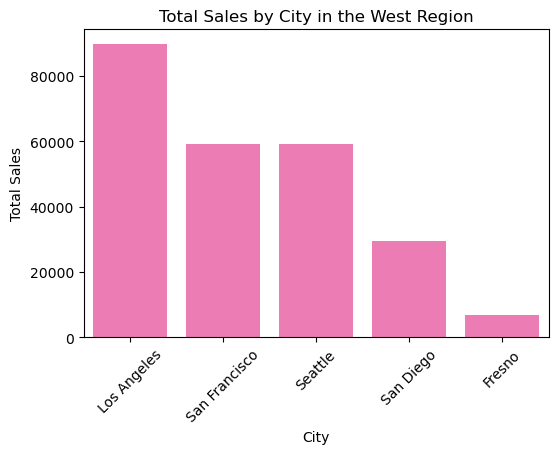

In [110]:
# The highest revenue generating cities in the West
west_cities = df_clean[df_clean['Region'] == 'West'].groupby('City')['Sales'].sum().reset_index()
west_cities.columns = ['City', 'Total Sales']
west_cities = west_cities.sort_values('Total Sales', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=west_cities.head(5), color='hotpink', x='City', y='Total Sales')
plt.xticks(rotation=45)
plt.title('Total Sales by City in the West Region')
plt.show()

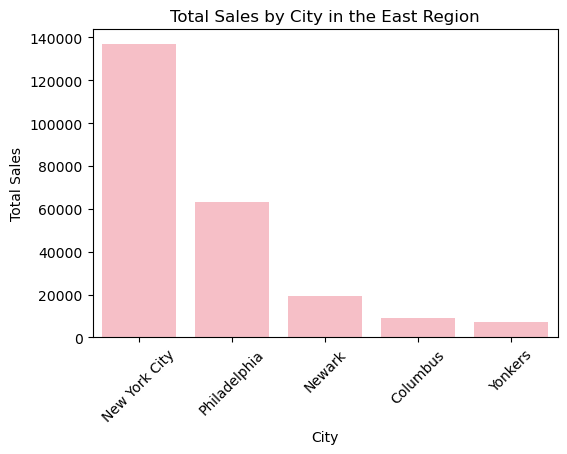

In [111]:
# The highest revenue generating cities in the east
east_cities = df_clean[df_clean['Region'] == 'East'].groupby('City')['Sales'].sum().reset_index()
east_cities.columns = ['City', 'Total Sales']
east_cities = east_cities.sort_values('Total Sales', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=east_cities.head(5), color='lightpink', x='City', y='Total Sales')
plt.xticks(rotation=45)
plt.title('Total Sales by City in the East Region')
plt.show()

**Los Angeles** is the highest revenue-generating city in the West, while **New York City** leads the East. New York City is also the highest revenue generating city overall.  

### **IV. Product Category Analysis** 
This section examines which product categories are the main generators of revenue and profit. This is done on both a regional and city level.


In [112]:
# Sorting the catgories by total sales (West)
west_category_sales = df_clean[df_clean['Region'] == 'West'].groupby('Category')['Sales'].sum().reset_index()
west_category_sales.columns = ['Category', 'Total Sales']
display(west_category_sales.sort_values('Total Sales', ascending=False))

total_west_sales = region_summary[region_summary['Region'] == 'West']['Total Sales'].values[0]
west_category_sales['Sales Share'] = (west_category_sales['Total Sales'] / total_west_sales * 100).round(2).astype(str) + '%'
display(west_category_sales.sort_values('Total Sales', ascending=False))

# Sorting the catgories by total sales (East)
east_category_sales = df_clean[df_clean['Region'] == 'East'].groupby('Category')['Sales'].sum().reset_index()
east_category_sales.columns = ['Category', 'Total Sales']
display(east_category_sales.sort_values('Total Sales', ascending=False))

total_east_sales = region_summary[region_summary['Region'] == 'East']['Total Sales'].values[0]
east_category_sales['Sales Share'] = (east_category_sales['Total Sales'] / total_east_sales * 100).round(2).astype(str) + '%'
display(east_category_sales.sort_values('Total Sales', ascending=False))

,Category,Total Sales
2,Technology,132991.746
0,Furniture,119808.087
1,Office Supplies,110080.940


,Category,Total Sales,Sales Share
2,Technology,132991.746,36.65%
0,Furniture,119808.087,33.02%
1,Office Supplies,110080.940,30.34%


,Category,Total Sales
2,Technology,135441.229
0,Furniture,114211.802
1,Office Supplies,101255.136


,Category,Total Sales,Sales Share
2,Technology,135441.229,38.6%
0,Furniture,114211.802,32.55%
1,Office Supplies,101255.136,28.86%


In [113]:
# Sorting the catgories by profit (West)
west_category_profit = df_clean[df_clean['Region'] == 'West'].groupby('Category')['Profit'].sum().reset_index()
west_category_profit.columns = ['Category', 'Total Profit']
display(west_category_profit.sort_values('Total Profit', ascending=False))

total_west_profit = region_summary[region_summary['Region'] == 'West']['Total Profit'].values[0]
west_category_profit['Profit Share'] = (west_category_profit['Total Profit'] / total_west_profit * 100).round(2).astype(str) + '%'
display(west_category_profit.sort_values('Total Profit', ascending=False))

# Sorting the catgories by profit (East)
east_category_profit = df_clean[df_clean['Region'] == 'East'].groupby('Category')['Profit'].sum().reset_index()
east_category_profit.columns = ['Category', 'Total Profit']
display(east_category_profit.sort_values('Total Profit', ascending=False))

total_east_profit = region_summary[region_summary['Region'] == 'East']['Total Profit'].values[0]
east_category_profit['Profit Share'] = (east_category_profit['Total Profit'] / total_east_profit * 100).round(2).astype(str) + '%'
display(east_category_profit.sort_values('Total Profit', ascending=False))

,Category,Total Profit
2,Technology,27785.5681
1,Office Supplies,25334.3679
0,Furniture,4330.6680


,Category,Total Profit,Profit Share
2,Technology,27785.5681,48.36%
1,Office Supplies,25334.3679,44.1%
0,Furniture,4330.6680,7.54%


,Category,Total Profit
2,Technology,19930.1794
1,Office Supplies,19222.6927
0,Furniture,2038.1122


,Category,Total Profit,Profit Share
2,Technology,19930.1794,48.38%
1,Office Supplies,19222.6927,46.67%
0,Furniture,2038.1122,4.95%


In [114]:
# Product categories by generated revenue for the city of Los Angeles
LA_category_sales = df_clean[df_clean['City'] == 'Los Angeles'].groupby('Category')['Sales'].sum().reset_index()
LA_category_sales.columns = ['Category', 'Total Sales']
display(LA_category_sales.sort_values('Total Sales', ascending=False))

total_LA_sales = west_cities[west_cities['City'] == 'Los Angeles']['Total Sales'].values[0]
LA_category_sales['Sales Share'] = (LA_category_sales['Total Sales'] / total_LA_sales * 100).round(2).astype(str) + '%'
display(LA_category_sales.sort_values('Total Sales', ascending=False))

# Product categories by generated revenue for New York City
NY_category_sales = df_clean[df_clean['City'] == 'New York City'].groupby('Category')['Sales'].sum().reset_index()
NY_category_sales.columns = ['Category', 'Total Sales']
display(NY_category_sales.sort_values('Total Sales', ascending=False))

total_NY_sales = east_cities[east_cities['City'] == 'New York City']['Total Sales'].values[0]
NY_category_sales['Sales Share'] = (NY_category_sales['Total Sales'] / total_NY_sales * 100).round(2).astype(str) + '%'
display(NY_category_sales.sort_values('Total Sales', ascending=False))

,Category,Total Sales
2,Technology,35621.2060
0,Furniture,28825.5965
1,Office Supplies,25229.8380


,Category,Total Sales,Sales Share
2,Technology,35621.2060,39.72%
0,Furniture,28825.5965,32.14%
1,Office Supplies,25229.8380,28.13%


,Category,Total Sales
2,Technology,50925.844
0,Furniture,49519.337
1,Office Supplies,36424.642


,Category,Total Sales,Sales Share
2,Technology,50925.844,37.21%
0,Furniture,49519.337,36.18%
1,Office Supplies,36424.642,26.61%


**Technology** is the largest category by both sales volume and profit contribution in both the West and East regions. Furniture generates approximately one third of revenue but accounts for only 7.5% of profit in the West and 5.0% in the East. Given that furniture is also the most logistically demanding category in terms of storage and floor space, **it may be worth considering a store format focused on Technology and Office Supplies only**. Finally, a city-level check confirms that the category breakdown in Los Angeles and New York City is consistent with the broader regional trends.

### **V. Exportable Raw Data & Results**

In [115]:
# Creating a summary table of regional results for exporting
summary_table = region_summary[['Region', 'Total Profit', 'Total Sales', 'Profit Margin']].sort_values('Total Profit', ascending=False)
display(summary_table)

,Region,Total Profit,Total Sales,Profit Margin
3,West,57450.6040,362880.773,0.158318
1,East,41190.9843,350908.167,0.117384
2,South,26913.5728,195580.971,0.137608
0,Central,8564.0481,252031.434,0.033980


In [116]:
# Creating exportable csv files

summary_table.to_csv('summary_results.csv', index=False)
df.to_csv('superstore_raw.csv', index=False)

print("Files exported successfully.")

Files exported successfully.


### **Conclusion**

Based on the analysis, Superstore is advised to open two smaller retail stores, one in **Los Angeles** and one in **New York City**. Los Angeles is the top performing city in the West, which is the strongest region overall, while New York City is the highest revenue-generating city across all regions and anchors the second strongest region in the East.

Both stores should operate **without a furniture department**. Furniture generates only 7.5% of profit in the West and 5.0% in the East despite accounting for roughly one third of sales volume, and it carries significant logistical requirements in terms of storage and floor space. Excluding furniture frees up capital and space for the two more profitable categories.

For the store in **Los Angeles**, the **technology** department should be allocated **58.5%** of the space while the **office supplies** should occupy around **41.5%** of the store. In **New York City**, **58.3%** of the shelf space should be allocated to the **technology** department while **office supplies** should occupy around **41.7%** of the store. The similarity in the split across both cities suggests a stable pattern. 

### Statement of AI Use

I have used AI (Claude) as a supportive tool in this project. AI helped me resolve issues in my code and it helped me improve my grammar/language. 